# Understanding the nucleosome curve

Why is it that nucleosome occupancy genome-wide appears to peak in G1 and drop dramatically in S and return in G2M?

Some prevailing hypotheses: 
1. The increase in copy number effects effectively doubles the amount of strands that nucleosomes can bind to. Strangely, we would expect this to occur in S, not in G1 phase.
2. There is a histone pool that increases in size in anticipation for replication (this theory requires literature review, but may be a feasible explanation if paired with histone gene expression)

How do we approach understanding this phenomena genome-wide? 
Plot the 10~kb occupancy windows for nucleosomes genome-wide. And we will be able to profile the occupancy curves. Expectation will be that they look very similar to the replication timing curves. 

Outstanding Questions:
- Which is expected, but does this analysis against the deconvolved windows provide additional insight? 
- Especially regarding the total peak and trough values of these occupancy values? 
- Is further normalization necessary?


In [384]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [382]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)

In [383]:
from src.chromatin_metrics import fragment_lengths_definitions

sm, mid, nuc = fragment_lengths_definitions()

t_indices = analysis.config.get_Hpositions_for_branch('t')
cg1_indices = analysis.config.get_Hpositions_for_phase('CG1')


AttributeError: 'GenomeDeconvolutionAnalysis' object has no attribute 'config'

In [ ]:
from src.timer import Timer

timer = Timer()

window_10k_definitions = pd.read_csv('data/reference_data/sacCer3_genome_10k_windows.csv')
window_10k_definitions = window_10k_definitions.set_index(['chr', 'start', 'end'])

nuc_win_10k_occupancy_curves = pd.DataFrame(index=window_10k_definitions.index,
                                       columns=range(178))
overall_win_10k_occupancy_curves = pd.DataFrame(index=window_10k_definitions.index,
                                       columns=range(178))
small_win_10k_occupancy_curves = pd.DataFrame(index=window_10k_definitions.index,
                                       columns=range(178))
i = 0
n = len(window_10k_definitions)

for index, _ in window_10k_definitions.iterrows():
    chrom, start, stop = index
    mnase_data, loaded_span = analysis.load_mnase_span(chrom, (start, stop))
    
    nuc_occ = mnase_data[:, nuc[0]//10:nuc[1]//10, :].sum(axis=1).sum(axis=1)
    overall_occ = mnase_data[:, :, :].sum(axis=1).sum(axis=1)
    sm_occ = mnase_data[:, sm[0]//10:sm[1]//10, :].sum(axis=1).sum(axis=1)
    
    overall_win_10k_occupancy_curves.loc[index, :] = overall_occ
    small_win_10k_occupancy_curves.loc[index, :] = sm_occ
    nuc_win_10k_occupancy_curves.loc[index, :] = nuc_occ

    if i % 200 == 0:
        timer.print_time(f"{i}/{n}")
    
    i += 1

In [ ]:
win_10k_occupancy_curves

In [ ]:
def plot_curve(curve):
    lower = curve.quantile(0.25, axis=0)[t_indices].astype(float)
    upper = curve.quantile(0.75, axis=0)[t_indices].astype(float)
    x = t_indices
    plt.fill_between(x, lower, upper, alpha=0.25)
    plt.plot(curve.median(axis=0)[t_indices])
    
fig = plt.figure(figsize=(24, 5))
plt.subplot(1, 4, 1)
plot_curve(overall_win_10k_occupancy_curves)
plt.title("Overall")

plt.subplot(1, 4, 2)
plot_curve(small_win_10k_occupancy_curves)
plt.title("Small")

plt.subplot(1, 4, 3)
plot_curve(nuc_win_10k_occupancy_curves)
plt.title("Nucleosomal")

plt.suptitle("Genome-wide occupancy")
plt.subplots_adjust(wspace=0.3, top=0.77)

plt.subplot(1, 4, 4)
plot_curve(overall_win_10k_occupancy_curves)
plot_curve(small_win_10k_occupancy_curves)
plot_curve(nuc_win_10k_occupancy_curves)

plt.suptitle("Genome-wide occupancy")
plt.subplots_adjust(wspace=0.3, top=0.77)

Observation: Overall, small and nucleosomal sized fragments follow the same overall curve
large occupancy in G1 followed by a drop in S.

The absolute scale of which is greater in nucleosomes than in small fragments. That is, 
the nucleosomal occupancy changes is greater than the small fragments, but when examined 
individually, the curves and quantiles are similar in shape and range.

This appears to be a total occupancy shape of the genome.

In [ ]:
chrom = 4

plt.figure(figsize=(13, 4))

plt.subplot(3, 1, 1)
plt.imshow(overall_win_10k_occupancy_curves.loc[chrom].astype(float)[t_indices].T, 
           vmin=25000, vmax=35000, aspect='auto', 
          origin='lower', interpolation='none', cmap='inferno')
plt.colorbar()
plt.xticks([])
plt.ylabel(f"Overall")

plt.subplot(3, 1, 2)
plt.imshow(nuc_win_10k_occupancy_curves.loc[chrom].astype(float)[t_indices].T, 
           vmin=7000, vmax=12000, aspect='auto', 
          origin='lower', interpolation='none', cmap='Spectral_r')
plt.colorbar()
plt.xticks([])
plt.ylabel(f"Nucleosomal")

plt.subplot(3, 1, 3)
plt.imshow(small_win_10k_occupancy_curves.loc[chrom].astype(float)[t_indices].T, 
           vmin=7000, vmax=12000, aspect='auto', 
          origin='lower', interpolation='none', cmap='Spectral_r')
plt.ylabel(f"Small")
plt.colorbar()
plt.xticks([])
plt.suptitle(f'Chromosome IV occupancy')

save_figure_for_paper('output/figures/Replication/ChrIV_Nucleosome_occupancy_10kb_replication.png')


In examining an individual chromosome, IV, the variation in the occupancy curve is notable. We can also see variation in the timing in which the occupancy rises back up to the peak value. The trough position is likely strongly correlated with replication timing (as per the previous deconvolution to identify replication timing).


In [ ]:
from src.reference_data import load_chrom_replication_timing
chrom_replication_timing = load_chrom_replication_timing()
chrom_replication_timing.head()

In [ ]:
from src.chromatin_model import draw_phase_label_annotations
from src.plot_helpers import plot_heatmap_cell_cycle_tps

occ_repl_df = overall_win_10k_occupancy_curves.join(chrom_replication_timing, how='inner')

plt.figure(figsize=(6, 6))
plot_data = occ_repl_df.sort_values('replication_time')[t_indices].astype(float)

# Try halving the CG1 indices
adjusted_plt_data = plot_data.copy()
#adjusted_plt_data[cg1_indices] = adjusted_plt_data[cg1_indices]*0.97

ax = plt.gca()
im1, im2 = plot_heatmap_cell_cycle_tps(ax, analysis.config, 
    adjusted_plt_data, vmin=25000, vmax=40000,
                           cmap='viridis')
cbar = plt.colorbar(im1)
cbar.ax.set_ylabel("All fragments occupancy", rotation=270, va='bottom')
plt.ylabel("10 kb genomic window, sorted by replication time")
plt.title("10 kb all fragment lengths occupancy\nsorted by replication time", pad=9)

plt.plot(occ_repl_df.replication_time.sort_values(), np.arange(len(occ_repl_df)),
        c='red', lw=1)


In [ ]:
from src.chromatin_model import draw_phase_label_annotations
from src.plot_helpers import plot_heatmap_cell_cycle_tps

occ_repl_df = nuc_win_10k_occupancy_curves.join(chrom_replication_timing, how='inner')

plt.figure(figsize=(6, 6))
plot_data = occ_repl_df.sort_values('replication_time')[t_indices].astype(float)

# Try halving the CG1 indices
adjusted_plt_data = plot_data.copy()
#adjusted_plt_data[cg1_indices] = adjusted_plt_data[cg1_indices]*0.97

ax = plt.gca()
im1, im2 = plot_heatmap_cell_cycle_tps(ax, analysis.config, 
    adjusted_plt_data, vmin=5000, vmax=12000,
                           cmap='viridis')
cbar = plt.colorbar(im1)
cbar.ax.set_ylabel("Nucleosome occupancy", rotation=270, va='bottom')
plt.ylabel("10 kb genomic window, sorted by replication time")
plt.title("10 kb nucleosome occupancy\nsorted by replication time", pad=9)

plt.plot(occ_repl_df.replication_time.sort_values(), np.arange(len(occ_repl_df)),
        c='red', lw=1)

from src.figure_configs import save_figure_for_paper

save_figure_for_paper('output/figures/Replication/Nucleosome_occupancy_10kb_replication.png')


10 kb nucleosome occupancy through the top branch (G1, S, G2M) sorted by replication time.

Summary of observations
1. The first 20% of the genome shows an increase in nucleosome occupancy through the end of G1 into S phase. The peak occupancy occurs in mid-to late G1.
2. The last 40% of the genome shows an immediate drop off in nucleosome occupancy going into S-phase, (for the last 30% this starts inside G1). The peak occupancy occurs at the end of G2M into G1.

Biological reasoning, possible sources/explanations:
1. Copy number - early replicating regions double the number of available DNA, where nucleosomes can bind effectively doubling the occupancy early on in S (could this begin earlier in G1? And thus late replicating regions reduce in occupancy as a way to keep the total total genome occupancy constant (normalization constraint prior to deconvolution, does it carry into the deconvolution results?).
2. Early replicating regions require a larger number of histones and nucleosome for genome stability and thus preempt replication by overproducing histones to be used following replication. Available histones are depleted following early replication, so later replicating regions take longer to reach deposit nucleosomes and reach maximal occupancy.

todo: review literature on histone deposition (Bonnie?) Yulong


In [ ]:
plt.figure(figsize=(8, 4))

plt_data = occ_repl_df.sort_values('replication_time')[t_indices].head(200).mean(axis=0)
plt_data[cg1_indices] = plt_data[cg1_indices]

plt.plot(plt_data, 
         label="Early replicating")

plt_data = occ_repl_df.sort_values('replication_time')[t_indices].tail(200).mean(axis=0)
plt_data[cg1_indices] = plt_data[cg1_indices]

plt.plot(plt_data, 
         label="Late replicating")
plt.legend()


In [ ]:
# Create plots for alex to compare the raw data curves for early and late replicating regions

from src.stepwise_replication_solver import StepReplicationChromatinDeconvolveSolver
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

mnase_analysis_rep1 = MNaseOriginAnalysis(replicate=1)
mnase_analysis_rep1.compute_bin_curves()

mnase_analysis_rep2 = MNaseOriginAnalysis(replicate=2)
mnase_analysis_rep2.compute_bin_curves()

In [ ]:
from src.stepwise_replication_solver import load_chrom_replication_profile

In [ ]:
unnormalized_total_occupancy = mnase_analysis_rep1.unnormalized_chr_bin_curves
normalized_total_occ = unnormalized_total_occupancy / unnormalized_total_occupancy.sum(axis=0).values.reshape((1, -1))\
    * len(unnormalized_total_occupancy)

In [ ]:
chrom_replication_profile = load_chrom_replication_profile()

Text(0.5, 1.0, 'Earliest 10% vs Latest 10%')

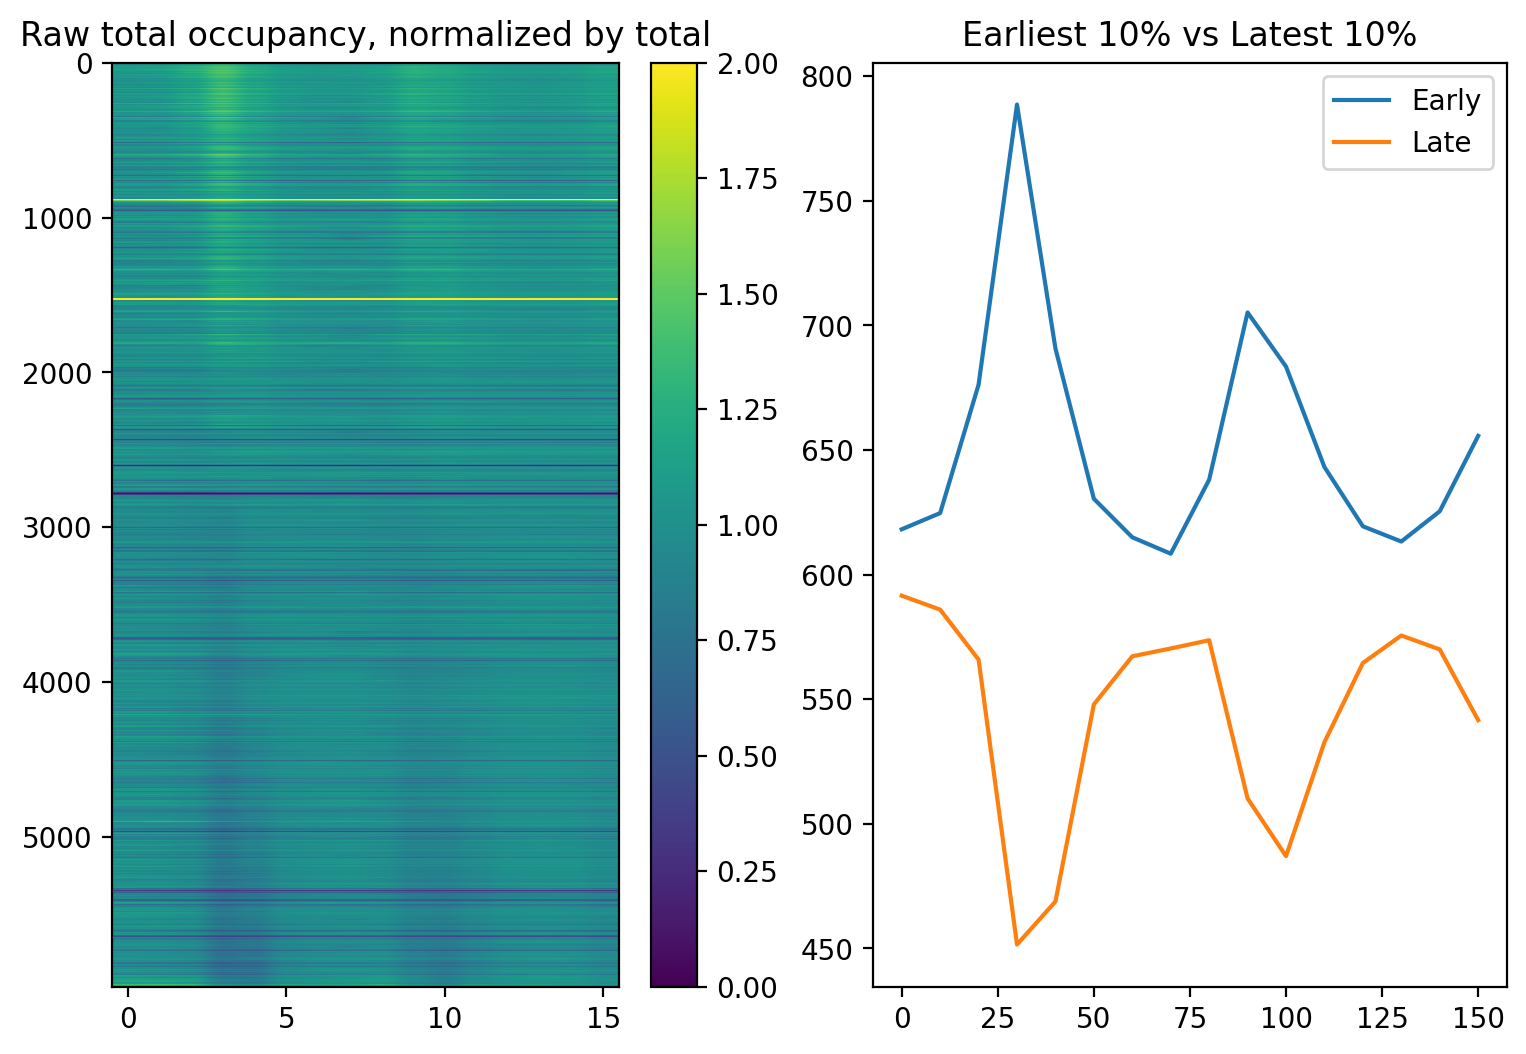

In [398]:
timepoints = unnormalized_total_occupancy.columns
sorted_occupacies = normalized_total_occ.join(chrom_replication_profile).sort_values('replication_index')

plt.figure(figsize=(9, 6))
plt.subplot(1, 2, 1)
plt.imshow(sorted_occupacies[timepoints], aspect='auto', vmin=0, vmax=2)
plt.colorbar()
plt.title("Raw total occupancy, normalized by total")

plt.subplot(1, 2, 2)
n = len(sorted_occupacies)
plt.plot(sorted_occupacies[timepoints].head(int(n*0.1)).sum(axis=0), label="Early")
plt.plot(sorted_occupacies[timepoints].tail(int(n*0.1)).sum(axis=0), label="Late")
plt.legend()
plt.title("Earliest 10% vs Latest 10%")


Text(0.5, 1.0, 'Chr10, equal sample normalization')

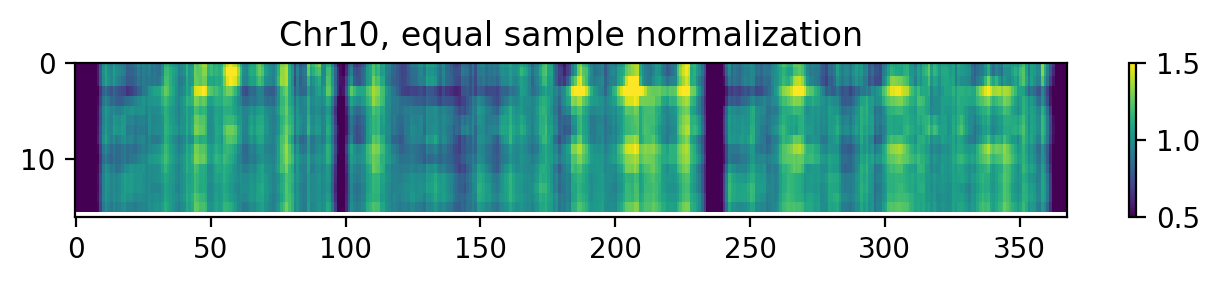

In [414]:
plt.figure(figsize=(8, 1))
plt.imshow(normalized_total_occ.loc[10].T, aspect='auto', interpolation='none',
          vmin=0.5, vmax=1.5, origin='lower')
plt.colorbar()
plt.ylim(len(normalized_total_occ.T), 0)
plt.title("Chr10, equal sample normalization")

Text(0.5, 1.0, 'Total occupancy, normalized by total\ngenomic order')

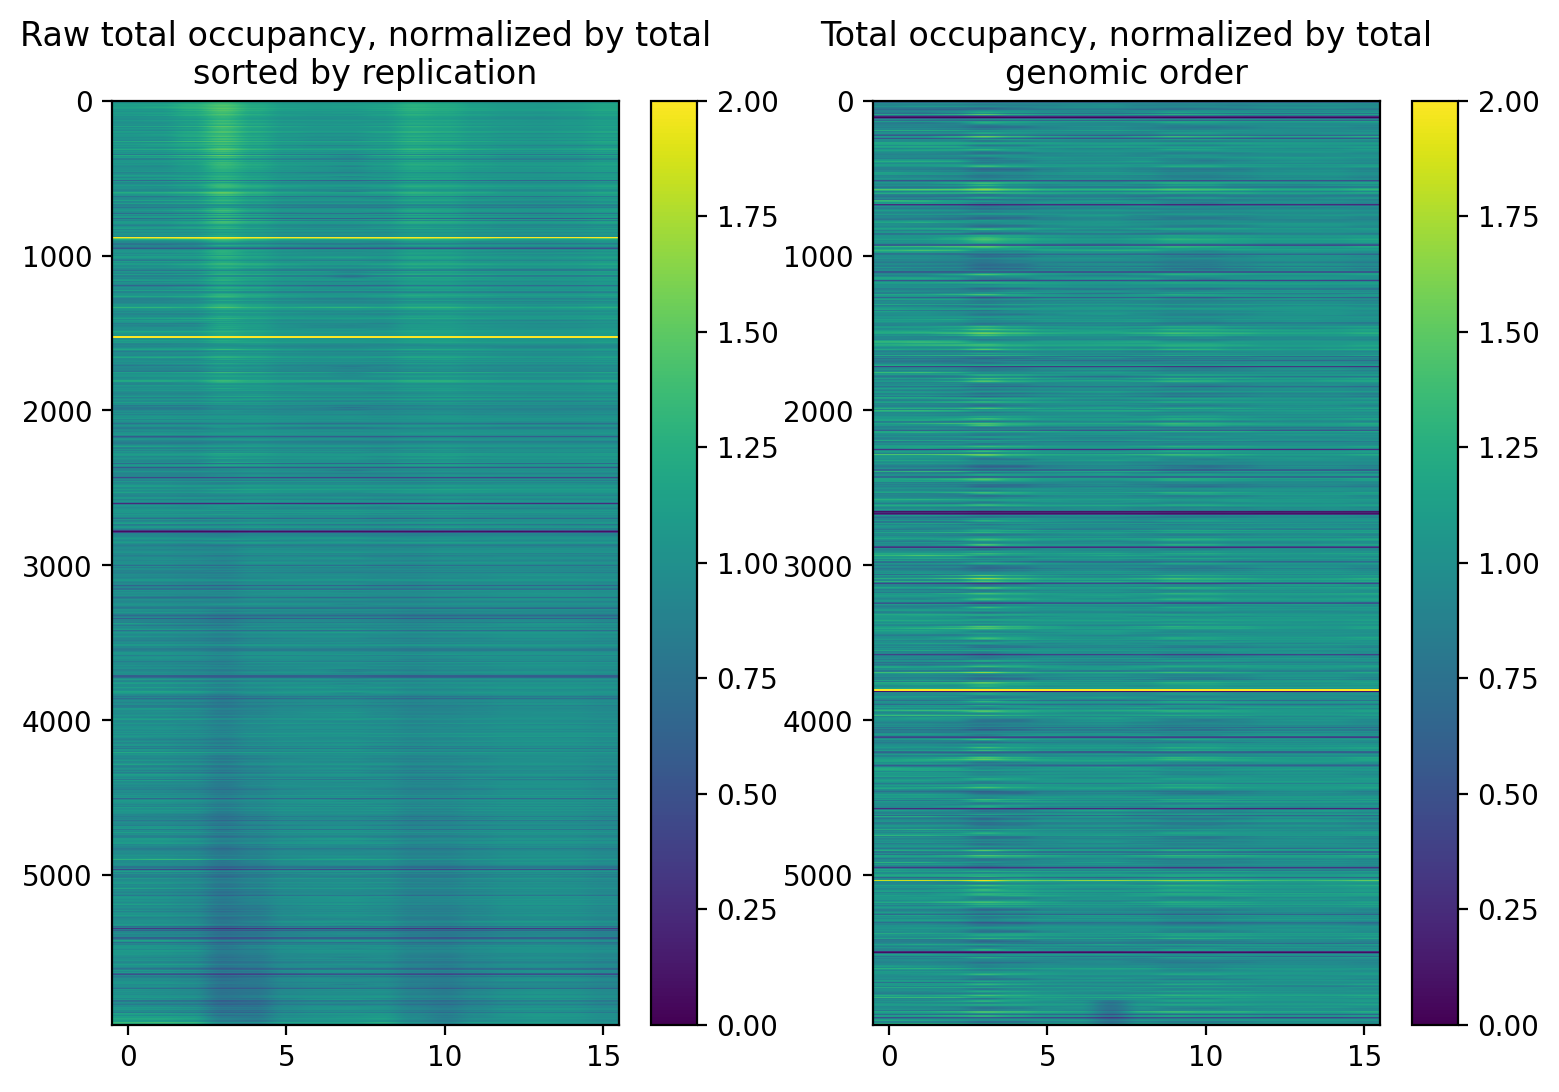

In [419]:
timepoints = unnormalized_total_occupancy.columns
sorted_occupacies = normalized_total_occ.join(chrom_replication_profile).sort_values('replication_index')

plt.figure(figsize=(9, 6))
plt.subplot(1, 2, 1)
plt.imshow(sorted_occupacies[timepoints], aspect='auto', vmin=0, vmax=2)
plt.colorbar()
plt.title("Raw total occupancy, normalized by total\nsorted by replication")

plt.subplot(1, 2, 2)
plt.imshow(normalized_total_occ[timepoints], aspect='auto', vmin=0, vmax=2)
plt.colorbar()
plt.title("Total occupancy, normalized by total\ngenomic order")


Text(0.5, 1.0, 'Total occupancy, unnormalized\ngenomic order')

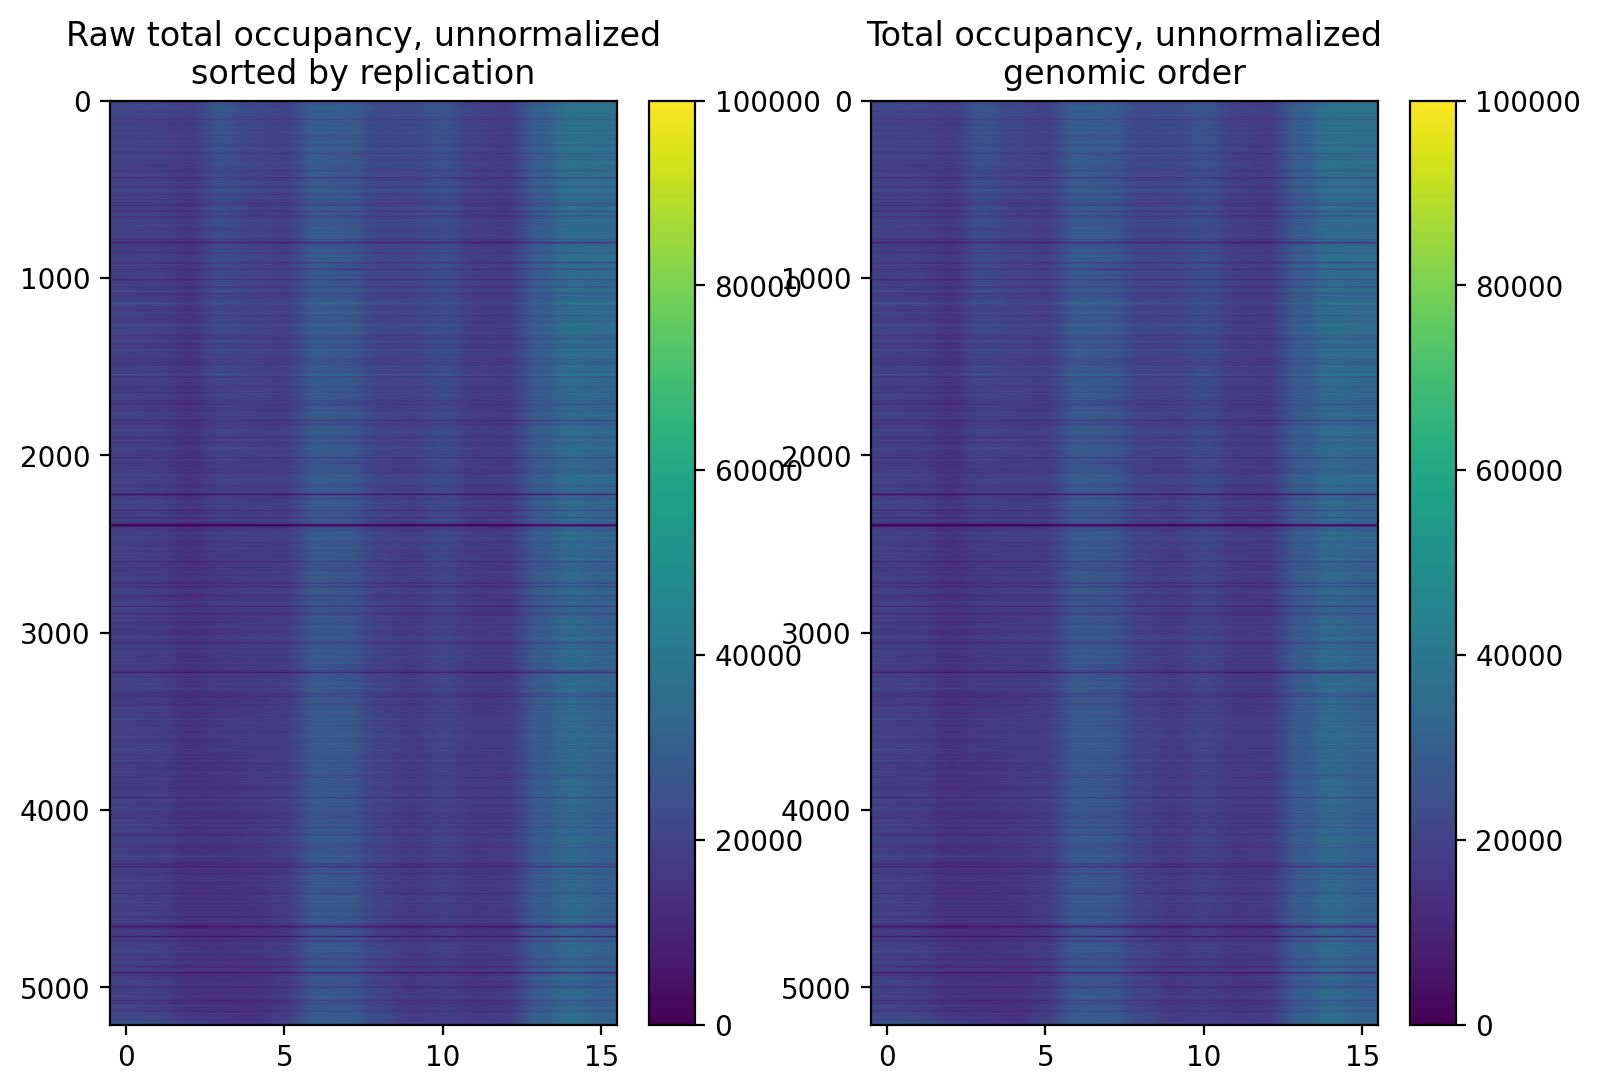

In [516]:
timepoints = unnormalized_total_occupancy.columns
sorted_occupacies = unnormalized_total_occupancy.join(chrom_replication_profile).sort_values('replication_index')

plt.figure(figsize=(9, 6))
plt.subplot(1, 2, 1)
plt.imshow(sorted_occupacies.loc[outside_range.index][timepoints], aspect='auto', vmin=0, vmax=100000)
plt.colorbar()
plt.title("Raw total occupancy, unnormalized\nsorted by replication")

plt.subplot(1, 2, 2)
plt.imshow(unnormalized_total_occupancy.loc[outside_range.index][timepoints], aspect='auto', vmin=0, vmax=100000)
plt.colorbar()
plt.title("Total occupancy, unnormalized\ngenomic order")


In [ ]:
# mask span
chrom = 12
mask_span = 435000, 475000


In [512]:
indices = sorted_occupacies.index

# Just get data within range (excluding chrom 12)
within_range = sorted_occupacies[
    (indices.get_level_values(0) != 12) & 
    (indices.get_level_values(1) >= 435000) &
    (indices.get_level_values(1) <= 475000)
]

# Just get data outside range (excluding chrom 12)
outside_range = sorted_occupacies[
    (indices.get_level_values(0) != 12) & 
    ~((indices.get_level_values(1) >= 435000) &
      (indices.get_level_values(1) <= 475000))
]

In [514]:
# perc_include = 0.333
# start, end = int(n/2 - n*perc_include/2), int(n/2 + n*perc_include/2)

# plt.plot(sorted_occupacies.loc[outside_range][start:end][tps].sum(axis=0))

# # What if we were to normalize by the middle third?
# middle_sum = sorted_occupacies.loc[outside_range][start:end][tps].sum(axis=0)

# plt.imshow(sorted_occupacies[tps] / middle_sum.values.reshape((1, -1)) * n, 
#            aspect='auto', vmin=0, vmax=10)
# plt.colorbar()

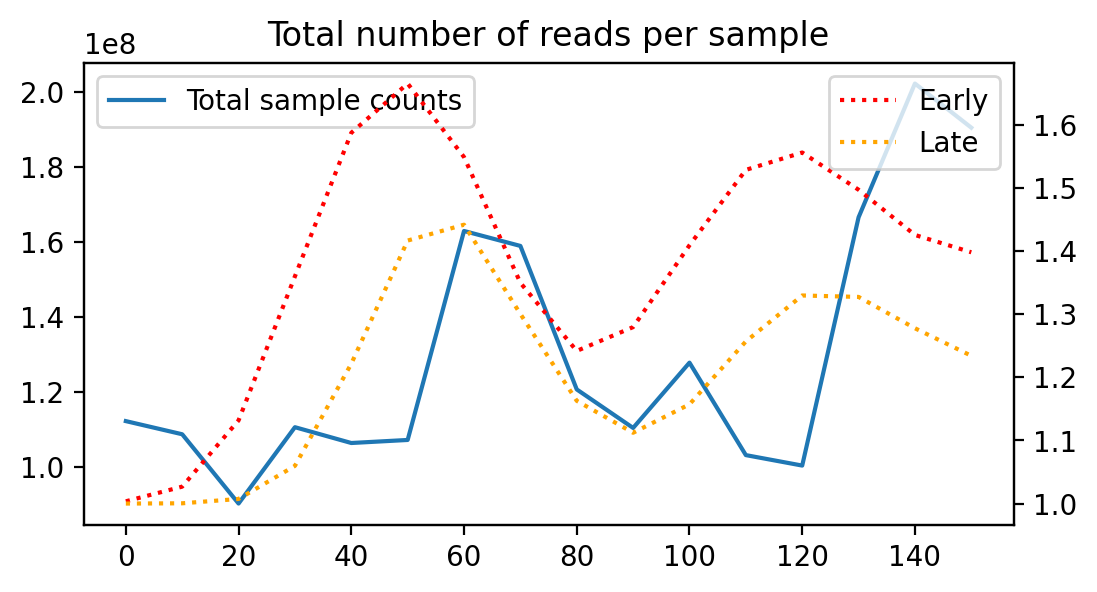

In [476]:
plt.figure(figsize=(6, 3))
plt.plot(unnormalized_total_occupancy.sum(axis=0), label="Total sample counts")
plt.title("Total number of reads per sample")
plt.legend()
tps = unnormalized_total_occupancy.columns

ax = plt.gca()
twinax = ax.twinx()
twinax.plot(tps, early_expected_DNA, c='red', ls='dotted', label="Early")
twinax.plot(tps, latest_expected_DNA, c='orange', ls='dotted', label="Late")
plt.legend()

In [440]:
H, _ = config1.calcH_function(config1.intervals_wt1, config1.WT1_TIMEPOINTS)

In [452]:
earliest_rows = sorted_occupacies.head(int(n*0.1))
latest_rows = sorted_occupacies.tail(int(n*0.1))

In [461]:
chrom, start = earliest_rows.index[0]

In [462]:
from src.GenomeDeconvolution import GenomeDeconvolution
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, (start, start+10000), log=False)

Adding a deconvolution offset to G: 1


In [463]:
from src.copy_correction_reanalysis import CopyCorrector
corrector = CopyCorrector(genome_deconvolution)
corrector.perform_correction(1)
early_expected_DNA = 1+corrector.replicated_proportion.sum(axis=1)

In [467]:
chrom, start = latest_rows.index[-1]
genome_deconvolution = GenomeDeconvolution(save_dir=None)
genome_deconvolution.load_chrom_span(chrom, (start, start+10000), log=False)

Adding a deconvolution offset to G: 1


In [468]:
from src.copy_correction_reanalysis import CopyCorrector
corrector = CopyCorrector(genome_deconvolution)
corrector.perform_correction(1)
latest_expected_DNA = 1+corrector.replicated_proportion.sum(axis=1)